# Lab 2 - Exploring and manipulating data with the Titanic dataset.
**Author:** Kellie Leopold  
**Date:** November 01, 2025  
**Objective:** Explore and manipulate the Titanic dataset to look for patterns, deal with missing values, and add in new features. 


## Introduction
In this project, I will use exploratory data analysis to analyze the Titanic dataset. This includes cleaning and preparing the data, handling missing values, and engineering new features to improve insight and support deeper analysis.

## Imports
Import the necessary Python libraries for this notebook.  

In [326]:
# Data manipulation and analysis
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

# Scikit-learn datasets and model tools
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split

## Section 1. Load and Explore the Data
Load the titanic dataset from the directly from the seaborn library for consistency and simplicity.
- Use info() to display basic information about the dataset.
- Use head() to display the first 10 rows.
- Use isnull().sum() to identify missing values in each column.
- Use describe() to see summary statistics.
- Use corr() to check for correlations and tell it to use only the numeric features.

In [327]:
# Load Titanic dataset
titanic = sns.load_dataset('titanic')

In [328]:
# Display basic information about the dataset using the info() method.
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [329]:
# Display the first 10 rows of data.
print(titanic.head(10))

   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

In [330]:
# Check for missing values using the isnull() method and then the sum() method.
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [331]:
# Display summary statistics using the describe() method.
print(titanic.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [332]:
# Check for correlations using the corr() method and tell it to use only the numeric features.
print(titanic.corr(numeric_only=True))

            survived    pclass       age     sibsp     parch      fare  \
survived    1.000000 -0.338481 -0.077221 -0.035322  0.081629  0.257307   
pclass     -0.338481  1.000000 -0.369226  0.083081  0.018443 -0.549500   
age        -0.077221 -0.369226  1.000000 -0.308247 -0.189119  0.096067   
sibsp      -0.035322  0.083081 -0.308247  1.000000  0.414838  0.159651   
parch       0.081629  0.018443 -0.189119  0.414838  1.000000  0.216225   
fare        0.257307 -0.549500  0.096067  0.159651  0.216225  1.000000   
adult_male -0.557080  0.094035  0.280328 -0.253586 -0.349943 -0.182024   
alone      -0.203367  0.135207  0.198270 -0.584471 -0.583398 -0.271832   

            adult_male     alone  
survived     -0.557080 -0.203367  
pclass        0.094035  0.135207  
age           0.280328  0.198270  
sibsp        -0.253586 -0.584471  
parch        -0.349943 -0.583398  
fare         -0.182024 -0.271832  
adult_male    1.000000  0.404744  
alone         0.404744  1.000000  


**Reflection 1:**
1) There are 891 instances and 15 features.
2) The names of the instances are: survived, pclass, sex, age, sibsp, parch, fare, embarked, class, who, adult_male, deck, embark_town, alive, and alone.
3) There are missing values in instances age, embarked, deck, and embark_town.
4) There are non-numeric colums in this dataset.

5) There are not data instances sorted on any of the attributes.
6) The age instance is measured in years.
7) The minimum age is less than a year, the median age is roughly 27, and the max age is 80.
8) The two features with the highest correlation are sibsp and alone with a correlation of approximately -0.58.

9)  Several categorical features could be useful for prediction, including sex, pclass, embarked, who, adult_male, and alone. These variables capture important patterns related to demographics, cabin class, and whether passengers traveled alone or with family. 

## Section 2. Data Exploration and Preparation
This section explores the dataset with charts and handles missing values

### 2.1 Explore Data Patterns and Distributions

- Create a scatter matrix.
- Create a scatter plot of age vs fare, colored by gender.
- Create a histogram of age.
- Create a count plot for class and survival.

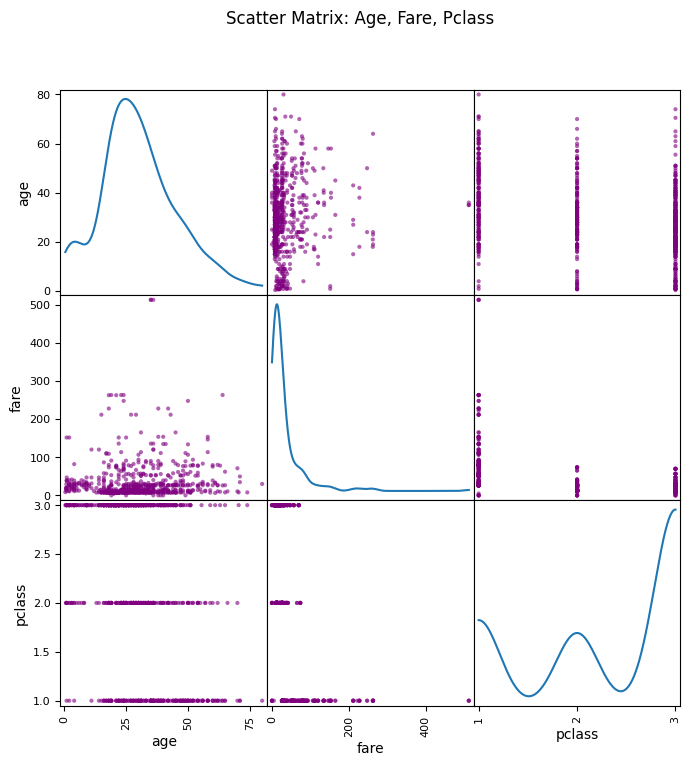

In [333]:
# Scatter matrix
attributes = ['age', 'fare', 'pclass']

scatter_matrix(
    titanic[attributes],
    figsize=(8, 8),
    alpha=0.6,
    color='purple',
    diagonal='kde'
)

plt.suptitle('Scatter Matrix: Age, Fare, Pclass')
plt.show()

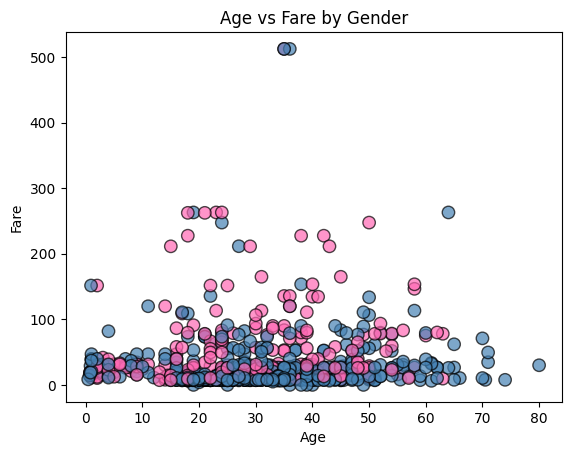

In [334]:
# Scatter plot
color_map = {'male': 'steelblue', 'female': 'hotpink'}

plt.scatter(
    titanic['age'],
    titanic['fare'],
    c=titanic['sex'].map(color_map),
    alpha=0.7,
    s=80,
    edgecolor='black'
)

plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare by Gender')
plt.show()

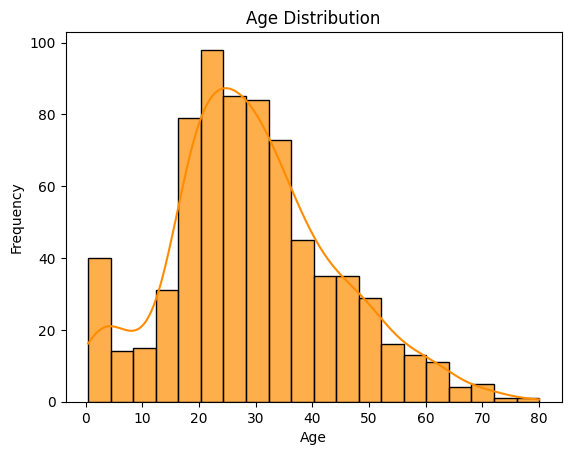

In [335]:
# Histogram
sns.histplot(titanic['age'], kde=True, color='darkorange', alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

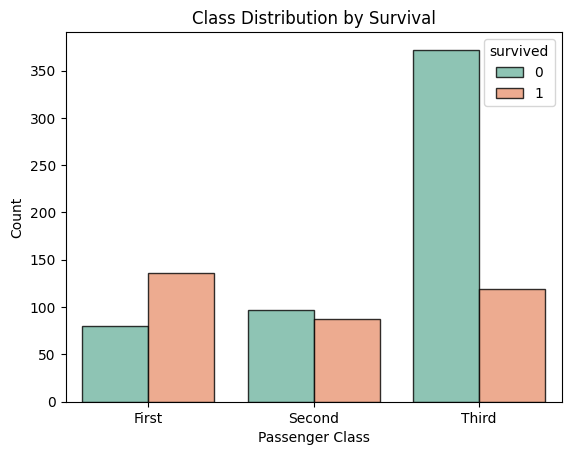

In [336]:
# Count plot
sns.countplot(
    x='class', 
    hue='survived', 
    data=titanic, 
    palette='Set2', 
    edgecolor='black', 
    alpha=0.8
)
plt.title('Class Distribution by Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()

**Reflection 2.1:**

Patterns I noticed:  
* Most passengers are clustered between ages 20-40, with fewer very young or elderly passengers. Note that there are some missing age values.
* Many passengers paid low fares, with only a few paying extremely high fares. This shows a right-skewed distribution. 
* Passengers in 1st class had a higher survival rate compared to 2nd and 3rd class.

Features that stand out as potential predictors:  
* Sex
* Pclass/Class
* Age
* Alone/Sibsp/Parch

Class imbalances:  
* More passengers did not survive than survived, and the majority of those were from the 3rd class. 
* There was a slight imbalance in sex, with more males than females on board.

### 2.2 Handle Missing values and Clean Data
Age and embark_town were missing values, so we will now impute the missing values using the median for age and drop the missing values for embark_town.

In [337]:
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

titanic['embark_town'] = titanic['embark_town'].fillna(titanic['embark_town'].mode()[0])

### 2.3 Feature Engineering
* Create a new feature: Family size.
* Convert categorical data to numeric.
* Create a binary feature for 'alone'.

In [338]:
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'C': 0, 'Q': 1, 'S': 2})

titanic['alone'] = titanic['alone'].astype(int)

**Reflection 2.3:**

* Family size combines multiple features into one that could impact survival.
* Converting categorical data to numeric allows machine learning models to process and learn from these features.  

## Section 3. Feature Selection and Justification
### 3.1 Choose features and target

- Input features: age, fare, pclass, sex, family_size
- Target: survived

### 3.2 Define X and y

- Assign input features to X.
- Assign target variable to y.

In [339]:
X = titanic[['age', 'fare', 'pclass', 'sex', 'family_size']]
y = titanic['survived']

**Reflection 3:**

* These features were selected because they are likely to influence a passenger's chance of survival based on historical patterns.
* The most predictive features are sex, pclass, and age, with family size and fare providing additional context. These features capture demographics, socio-economic status, and social context, all of which influenced survival on the Titanic.

## Section 4. Splitting
Split the data into training and test sets using train_test_split first and StratifiedShuffleSplit second. Compare.


In [340]:
# Basic Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

print('Train size:', len(X_train))
print('Test size:', len(X_test))

Train size: 712
Test size: 179


In [341]:
# Stratified Train/Test Split
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

for train_indices, test_indices in splitter.split(X, y):
    train_set = X.iloc[train_indices]
    test_set = X.iloc[test_indices]

print('Train size:', len(train_set))
print('Test size:', len(test_set))

Train size: 712
Test size: 179


In [342]:
# Compare results
print("Original Class Distribution:\n", y.value_counts(normalize=True))
print("Train Set Class Distribution:\n", train_set['pclass'].value_counts(normalize=True))
print("Test Set Class Distribution:\n", test_set['pclass'].value_counts(normalize=True))

Original Class Distribution:
 survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
Train Set Class Distribution:
 pclass
3    0.561798
1    0.227528
2    0.210674
Name: proportion, dtype: float64
Test Set Class Distribution:
 pclass
3    0.508380
1    0.301676
2    0.189944
Name: proportion, dtype: float64


**Reflection 4:**

* Stratification ensures that the class proportions in the training and test sets match the original dataset.
* In a basic train/test split, class distributions can vary randomly. With a stratified split, the distributions in both sets closely reflect the original data.
* The stratified split produced better class balance because it preserves the original class proportions in both the training and test sets.